# Individual LSTM Experiment Univariat Dengan Lookback 30

### 1. Import Library dan Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_log_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

# Set seed untuk reproduktibilitas
np.random.seed(42)
tf.random.set_seed(42)

### 2. Load Dataset
Memuat dataset `train.csv`.

In [2]:
# Load dataset
df_train = pd.read_csv('../datasets/train.csv', parse_dates=['date'])
df_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


### 3. Fungsi Pembantu (Data Preparation, Model Building, & Evaluasi)
Fungsi-fungsi pembantu ini digunakan untuk mempersiapkan data sekuensial, membuat model LSTM (Sederhana & Kompleks), serta melakukan proses latih dan evaluasi untuk setiap kombinasi store dan family.

> **Catatan Penting Pelatihan**: Model dilatih menggunakan `loss='mse'` (Mean Squared Error) pada data terskala `[0, 1]` untuk mencegah masalah *vanishing gradient* / *predictions stuck at 0* pada fungsi `msle`. Evaluasi akhir tetap diukur menggunakan metrik **RMSLE** (Root Mean Squared Logarithmic Error).

In [3]:
def create_dataset(dataset, look_back=30):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

def prepare_data_lstm(df, store_nbr, family, look_back=30, train_ratio=0.8):
    df_filtered = df[(df['store_nbr'] == store_nbr) & (df['family'] == family)]
    df_filtered = df_filtered.groupby('date')['sales'].sum().reset_index().set_index('date').asfreq('D').fillna(0).reset_index()

    sales_data = df_filtered['sales'].values.reshape(-1, 1)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(sales_data)

    X, y = create_dataset(scaled_data, look_back)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    train_size = int(len(X) * train_ratio)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    actual_sales = sales_data[look_back:]
    actual_y_test = actual_sales[train_size:]

    return {
        'df_filtered': df_filtered,
        'scaler': scaler,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'actual_y_test': actual_y_test,
        'look_back': look_back
    }

def build_simple_lstm(look_back=30):
    tf.random.set_seed(42)
    model = Sequential()
    model.add(LSTM(64, activation='tanh', dropout=0.2, input_shape=(look_back, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_complex_lstm(look_back=30):
    tf.random.set_seed(42)
    model = Sequential()
    model.add(LSTM(64, activation='tanh', return_sequences=True, input_shape=(look_back, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(32, activation='tanh'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def train_and_evaluate(model, data_dict, model_name, store_nbr, family, epochs=50, batch_size=32):
    X_train = data_dict['X_train']
    y_train = data_dict['y_train']
    X_test = data_dict['X_test']
    y_test = data_dict['y_test']
    scaler = data_dict['scaler']
    actual_y_test = data_dict['actual_y_test']
    df_filtered = data_dict['df_filtered']

    print(f"=== Training {model_name} (Store {store_nbr} - {family}) ===")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )

    # Plot Learning Curve
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.title(f'Learning Curve {model_name} - Store {store_nbr} | {family}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Prediksi & Inverse Transform
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_pred = np.where(y_pred < 0, 0, y_pred)

    # RMSLE Evaluation
    rmsle = root_mean_squared_log_error(actual_y_test, y_pred)
    print(f"[{model_name}] RMSLE (Store {store_nbr} - {family}): {rmsle:.4f}\n")

    # Plot Actual vs Predicted
    plt.figure(figsize=(14, 5))
    plt.plot(df_filtered['date'].iloc[-len(actual_y_test):], actual_y_test, label='Actual Sales', color='blue')
    plt.plot(df_filtered['date'].iloc[-len(y_pred):], y_pred, label=f'Predicted Sales ({model_name})', color='red', alpha=0.8)
    plt.title(f'Actual vs Predicted Sales ({model_name}) - Store {store_nbr} | {family}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

    return rmsle

---
## Kombinasi 1: Store 23 - EGGS

In [4]:
# Prepare Data Kombinasi 1 (Store 23, EGGS)
data_comb1 = prepare_data_lstm(df_train, store_nbr=23, family='EGGS')
print(f"Data Kombinasi 1 (Store 23 - EGGS) Siap!")
print(f"Shape X_train: {data_comb1['X_train'].shape}, Shape X_test: {data_comb1['X_test'].shape}")

Data Kombinasi 1 (Store 23 - EGGS) Siap!
Shape X_train: (1326, 30, 1), Shape X_test: (332, 30, 1)


### Kombinasi 1 - Model LSTM Sederhana

=== Training Simple LSTM (Store 23 - EGGS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0743 - val_loss: 0.0101
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0189 - val_loss: 0.0099
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0126 - val_loss: 0.0102
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0123 - val_loss: 0.0101
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0123 - val_loss: 0.0101
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0123 - val_loss: 0.0101
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0123 - val_loss: 0.0101
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0122 - val_loss: 0.0100
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0123 - val_loss: 0.0100
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0122 - val_loss: 0.0100
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0121 - val_loss: 0.0099
Epoch 12/50
42

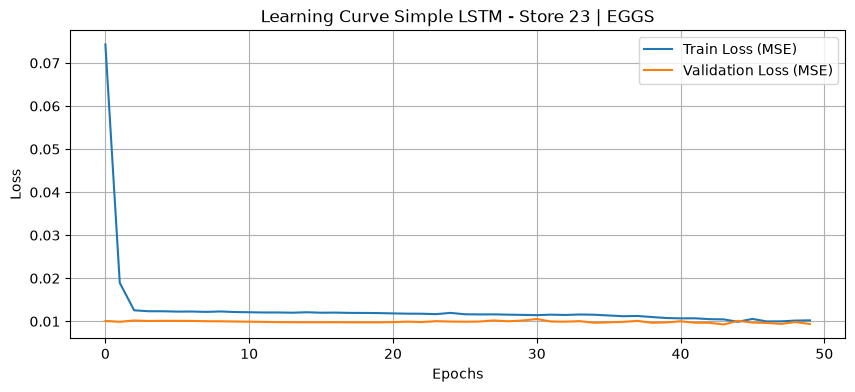

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
[Simple LSTM] RMSLE (Store 23 - EGGS): 0.3662



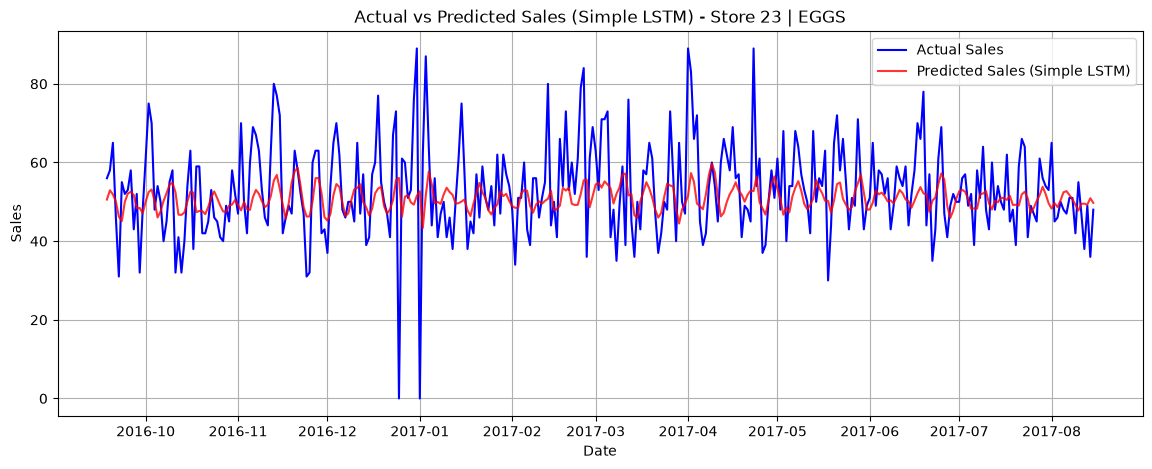

In [5]:
model_simple_comb1 = build_simple_lstm()
rmsle_simple_comb1 = train_and_evaluate(
    model_simple_comb1, data_comb1, 
    model_name="Simple LSTM", store_nbr=23, family="EGGS", 
    epochs=50, batch_size=32
)

### Kombinasi 1 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 23 - EGGS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - loss: 0.0369 - val_loss: 0.0101
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0148 - val_loss: 0.0101
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0141 - val_loss: 0.0101
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0142 - val_loss: 0.0101
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0146 - val_loss: 0.0103
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0146 - val_loss: 0.0100
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0141 - val_loss: 0.0102
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0137 - val_loss: 0.0100
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0136 - val_loss: 0.0103
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0137 - val_loss: 0.0100
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0130 - val_loss: 0.0101
Epoch 12/50
42

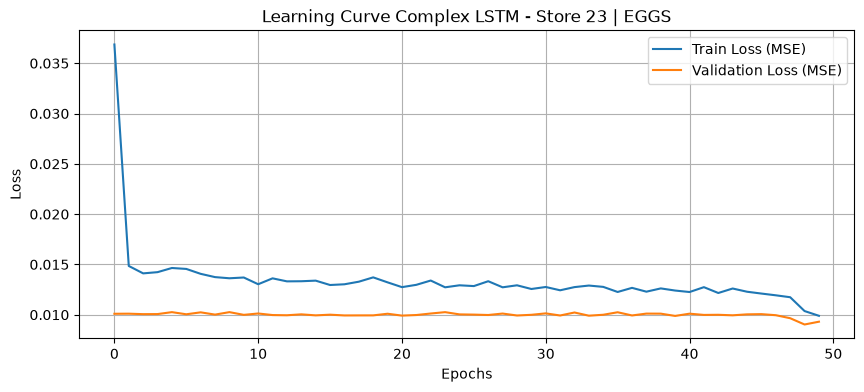

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
[Complex LSTM] RMSLE (Store 23 - EGGS): 0.3733



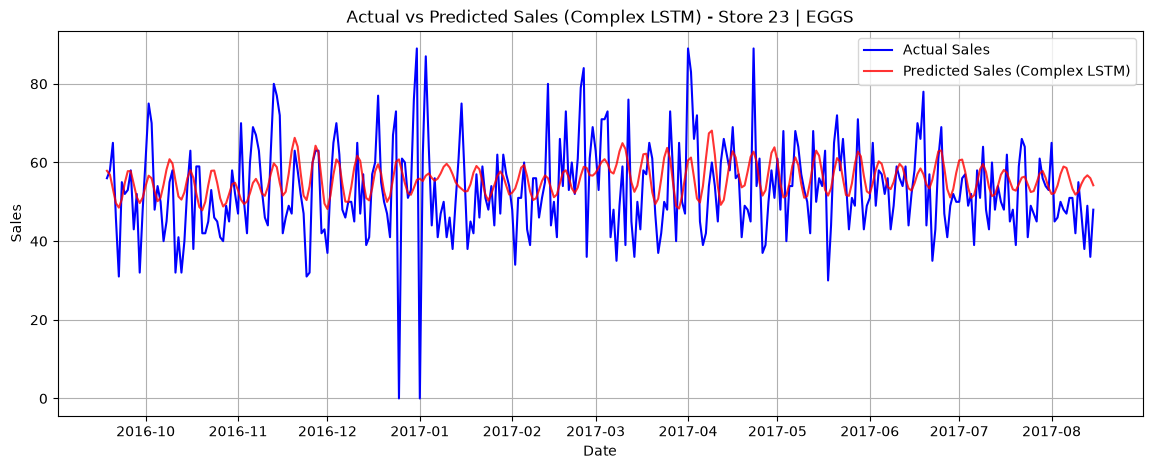

In [6]:
model_complex_comb1 = build_complex_lstm()
rmsle_complex_comb1 = train_and_evaluate(
    model_complex_comb1, data_comb1, 
    model_name="Complex LSTM", store_nbr=23, family="EGGS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 2: Store 54 - MEATS

In [7]:
# Prepare Data Kombinasi 2 (Store 54, MEATS)
data_comb2 = prepare_data_lstm(df_train, store_nbr=54, family='MEATS')
print(f"Data Kombinasi 2 (Store 54 - MEATS) Siap!")
print(f"Shape X_train: {data_comb2['X_train'].shape}, Shape X_test: {data_comb2['X_test'].shape}")

Data Kombinasi 2 (Store 54 - MEATS) Siap!
Shape X_train: (1326, 30, 1), Shape X_test: (332, 30, 1)


### Kombinasi 2 - Model LSTM Sederhana

=== Training Simple LSTM (Store 54 - MEATS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.0468 - val_loss: 0.0127
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0227 - val_loss: 0.0132
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0197 - val_loss: 0.0124
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0194 - val_loss: 0.0129
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0192 - val_loss: 0.0133
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0191 - val_loss: 0.0133
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0192 - val_loss: 0.0138
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0191 - val_loss: 0.0139
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0190 - val_loss: 0.0140
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0189 - val_loss: 0.0141
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0187 - val_loss: 0.0141
Epoch 12/50
42/

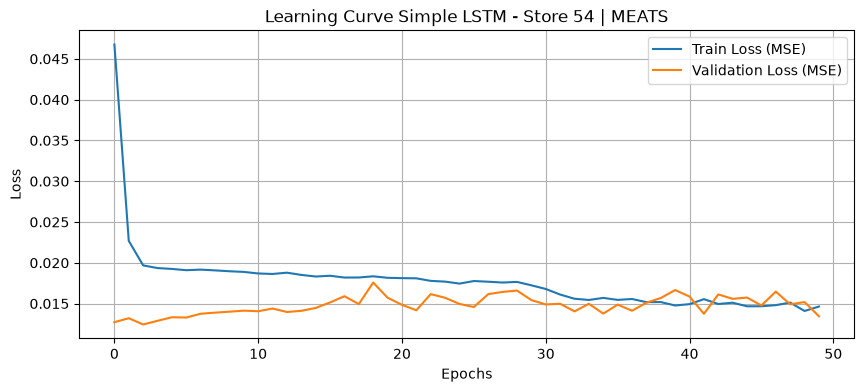

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step
[Simple LSTM] RMSLE (Store 54 - MEATS): 0.3955



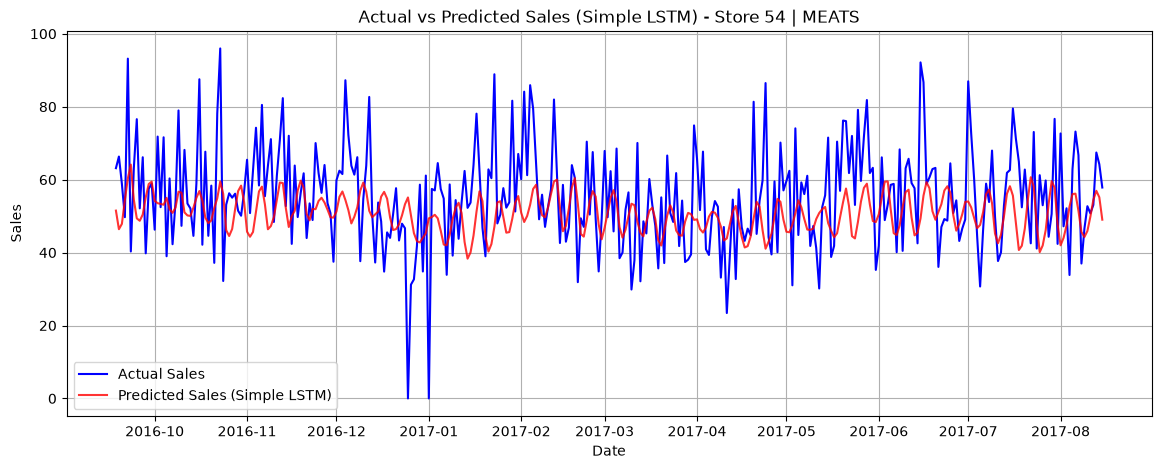

In [8]:
model_simple_comb2 = build_simple_lstm()
rmsle_simple_comb2 = train_and_evaluate(
    model_simple_comb2, data_comb2, 
    model_name="Simple LSTM", store_nbr=54, family="MEATS", 
    epochs=50, batch_size=32
)

### Kombinasi 2 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 54 - MEATS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - loss: 0.0394 - val_loss: 0.0123
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0201 - val_loss: 0.0124
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0206 - val_loss: 0.0121
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0197 - val_loss: 0.0120
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0203 - val_loss: 0.0120
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0198 - val_loss: 0.0120
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0194 - val_loss: 0.0120
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0193 - val_loss: 0.0123
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - loss: 0.0195 - val_loss: 0.0120
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0195 - val_loss: 0.0121
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0196 - val_loss: 0.0122
Epoch 12/50

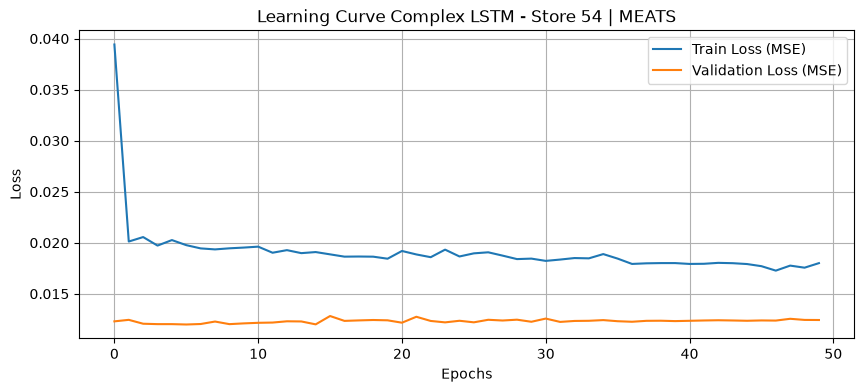

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step
[Complex LSTM] RMSLE (Store 54 - MEATS): 0.3901



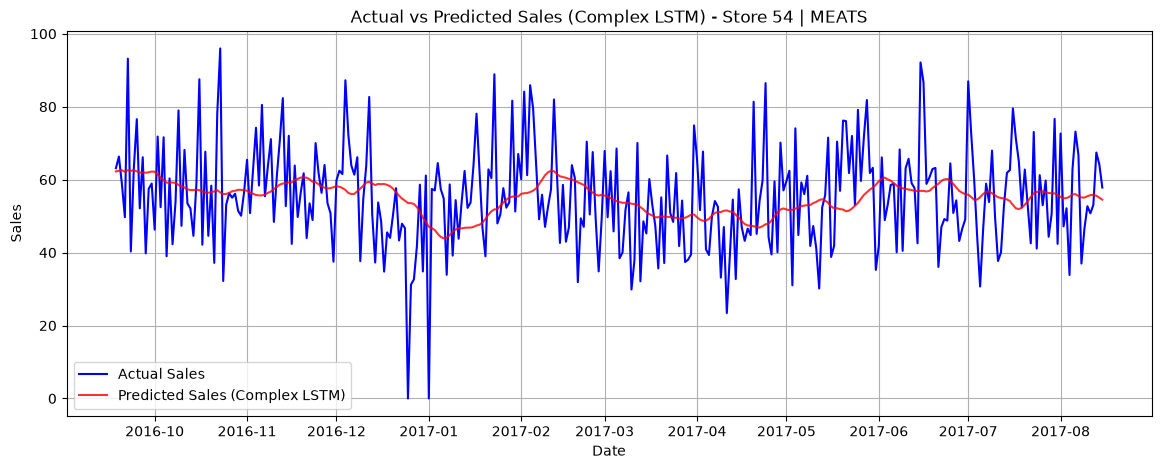

In [9]:
model_complex_comb2 = build_complex_lstm()
rmsle_complex_comb2 = train_and_evaluate(
    model_complex_comb2, data_comb2, 
    model_name="Complex LSTM", store_nbr=54, family="MEATS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 3: Store 19 - PREPARED FOODS

In [10]:
# Prepare Data Kombinasi 3 (Store 19, PREPARED FOODS)
data_comb3 = prepare_data_lstm(df_train, store_nbr=19, family='PREPARED FOODS')
print(f"Data Kombinasi 3 (Store 19 - PREPARED FOODS) Siap!")
print(f"Shape X_train: {data_comb3['X_train'].shape}, Shape X_test: {data_comb3['X_test'].shape}")

Data Kombinasi 3 (Store 19 - PREPARED FOODS) Siap!
Shape X_train: (1326, 30, 1), Shape X_test: (332, 30, 1)


### Kombinasi 3 - Model LSTM Sederhana

=== Training Simple LSTM (Store 19 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0464 - val_loss: 0.0293
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0251 - val_loss: 0.0312
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0233 - val_loss: 0.0312
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0228 - val_loss: 0.0318
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0229 - val_loss: 0.0322
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0223 - val_loss: 0.0331
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0212 - val_loss: 0.0315
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0219 - val_loss: 0.0306
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0214 - val_loss: 0.0318
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0213 - val_loss: 0.0324
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0207 - val_loss: 0.0307
Epoch 

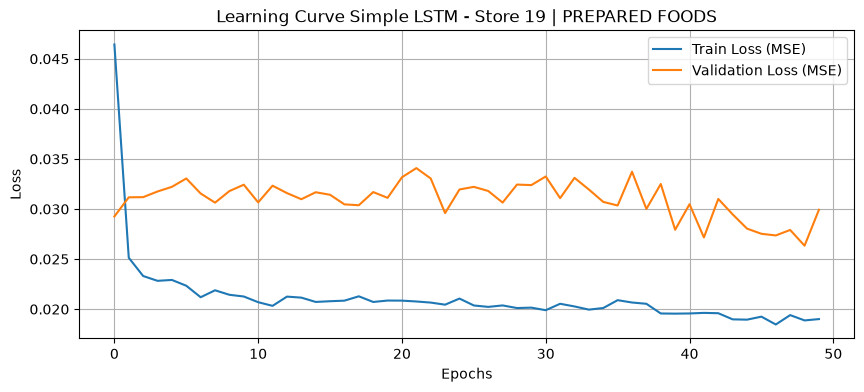

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
[Simple LSTM] RMSLE (Store 19 - PREPARED FOODS): 0.4276



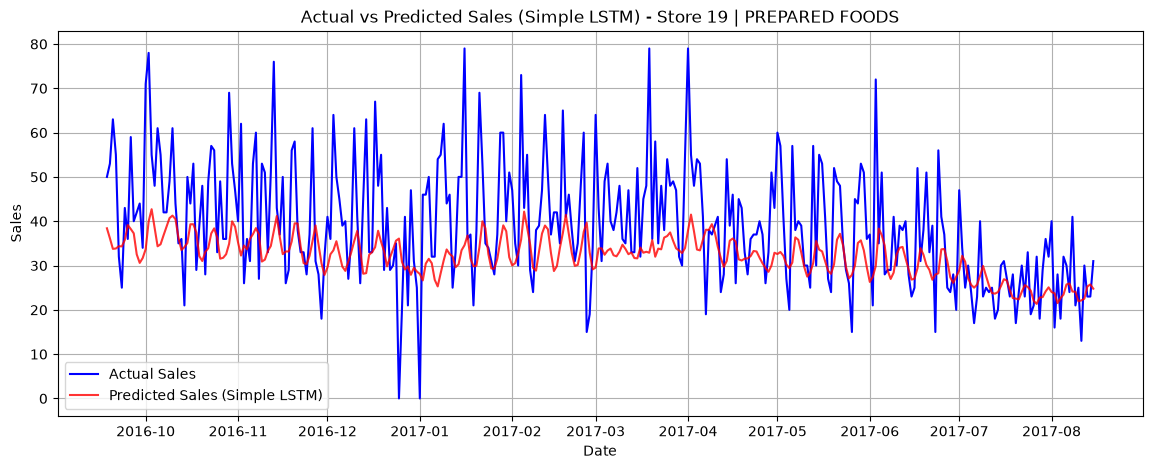

In [11]:
model_simple_comb3 = build_simple_lstm()
rmsle_simple_comb3 = train_and_evaluate(
    model_simple_comb3, data_comb3, 
    model_name="Simple LSTM", store_nbr=19, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

### Kombinasi 3 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 19 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - loss: 0.0334 - val_loss: 0.0259
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0209 - val_loss: 0.0245
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0220 - val_loss: 0.0241
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0210 - val_loss: 0.0247
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0216 - val_loss: 0.0243
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0215 - val_loss: 0.0244
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0214 - val_loss: 0.0245
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0210 - val_loss: 0.0245
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0214 - val_loss: 0.0249
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0209 - val_loss: 0.0246
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0215 - val_loss: 0.0245
Epo

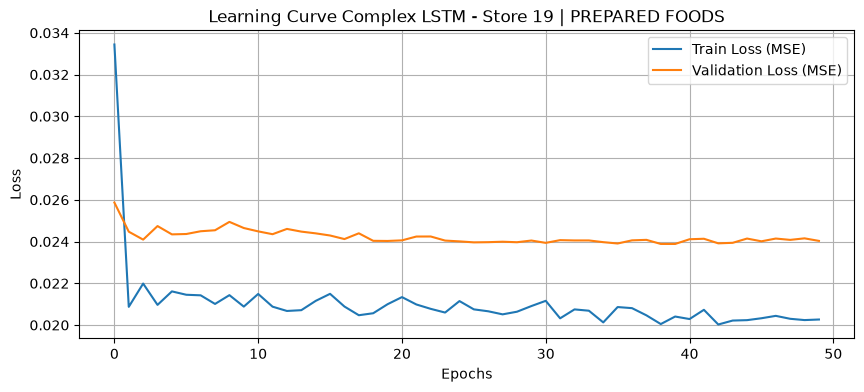

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step
[Complex LSTM] RMSLE (Store 19 - PREPARED FOODS): 0.4174



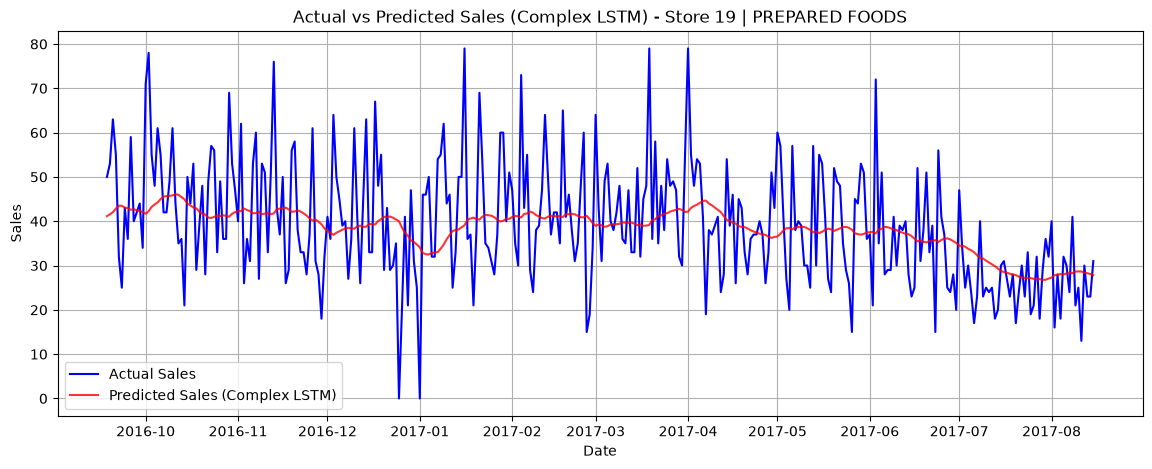

In [12]:
model_complex_comb3 = build_complex_lstm()
rmsle_complex_comb3 = train_and_evaluate(
    model_complex_comb3, data_comb3, 
    model_name="Complex LSTM", store_nbr=19, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 4: Store 7 - SEAFOOD

In [13]:
# Prepare Data Kombinasi 4 (Store 7, SEAFOOD)
data_comb4 = prepare_data_lstm(df_train, store_nbr=7, family='SEAFOOD')
print(f"Data Kombinasi 4 (Store 7 - SEAFOOD) Siap!")
print(f"Shape X_train: {data_comb4['X_train'].shape}, Shape X_test: {data_comb4['X_test'].shape}")

Data Kombinasi 4 (Store 7 - SEAFOOD) Siap!
Shape X_train: (1326, 30, 1), Shape X_test: (332, 30, 1)


### Kombinasi 4 - Model LSTM Sederhana

=== Training Simple LSTM (Store 7 - SEAFOOD) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 0.0567 - val_loss: 0.0168
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0249 - val_loss: 0.0294
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0203 - val_loss: 0.0254
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0201 - val_loss: 0.0234
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0198 - val_loss: 0.0221
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0193 - val_loss: 0.0198
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0194 - val_loss: 0.0172
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0188 - val_loss: 0.0166
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0190 - val_loss: 0.0155
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0193 - val_loss: 0.0154
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0190 - val_loss: 0.0155
Epoch 12/50
42

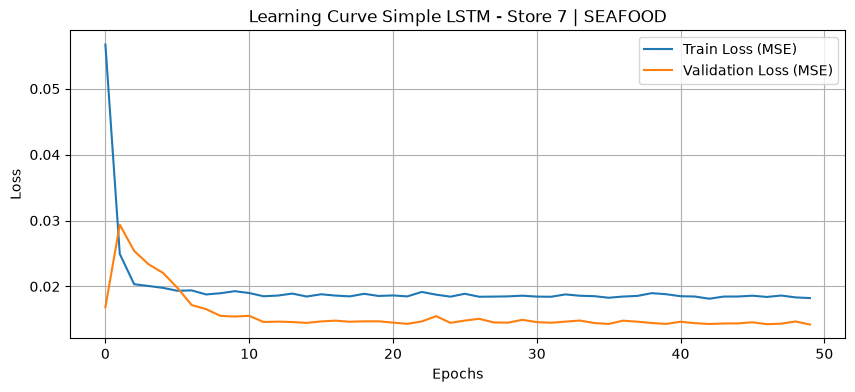

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
[Simple LSTM] RMSLE (Store 7 - SEAFOOD): 0.4241



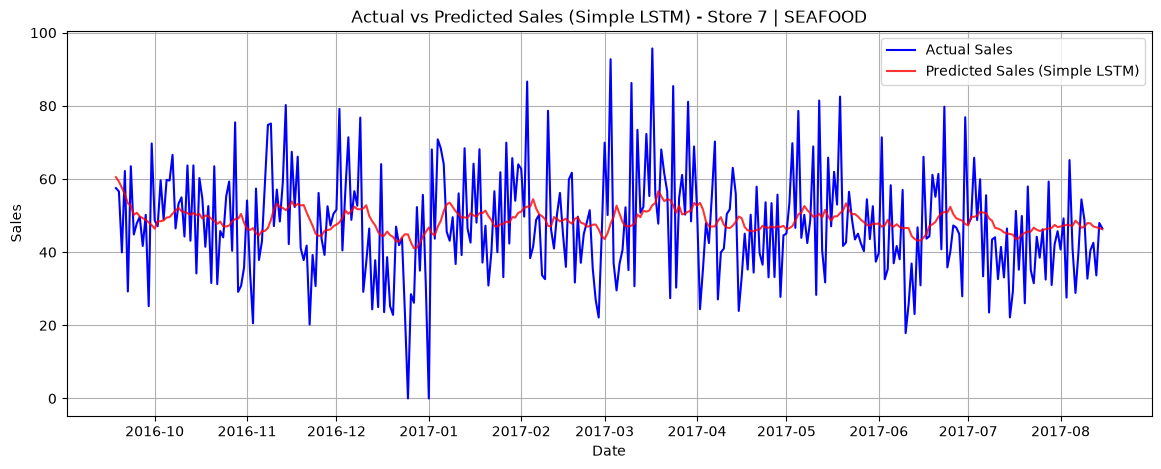

In [14]:
model_simple_comb4 = build_simple_lstm()
rmsle_simple_comb4 = train_and_evaluate(
    model_simple_comb4, data_comb4, 
    model_name="Simple LSTM", store_nbr=7, family="SEAFOOD", 
    epochs=50, batch_size=32
)

### Kombinasi 4 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 7 - SEAFOOD) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - loss: 0.0455 - val_loss: 0.0168
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0214 - val_loss: 0.0175
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0212 - val_loss: 0.0174
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0210 - val_loss: 0.0169
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0205 - val_loss: 0.0157
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0207 - val_loss: 0.0171
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0203 - val_loss: 0.0159
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0205 - val_loss: 0.0176
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0199 - val_loss: 0.0173
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0199 - val_loss: 0.0168
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0200 - val_loss: 0.0161
Epoch 12/50


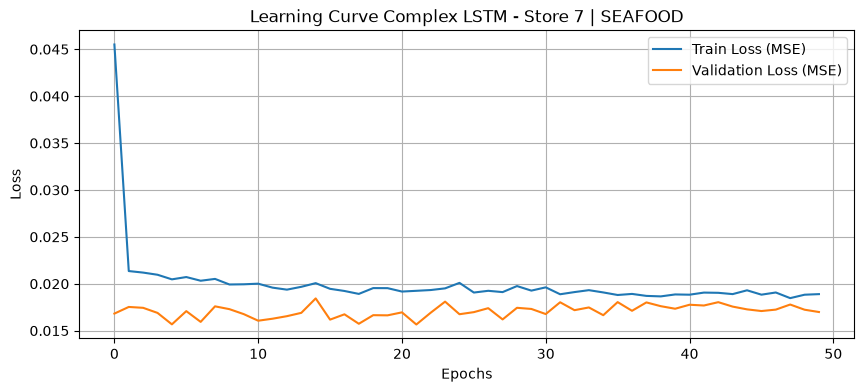

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step
[Complex LSTM] RMSLE (Store 7 - SEAFOOD): 0.4494



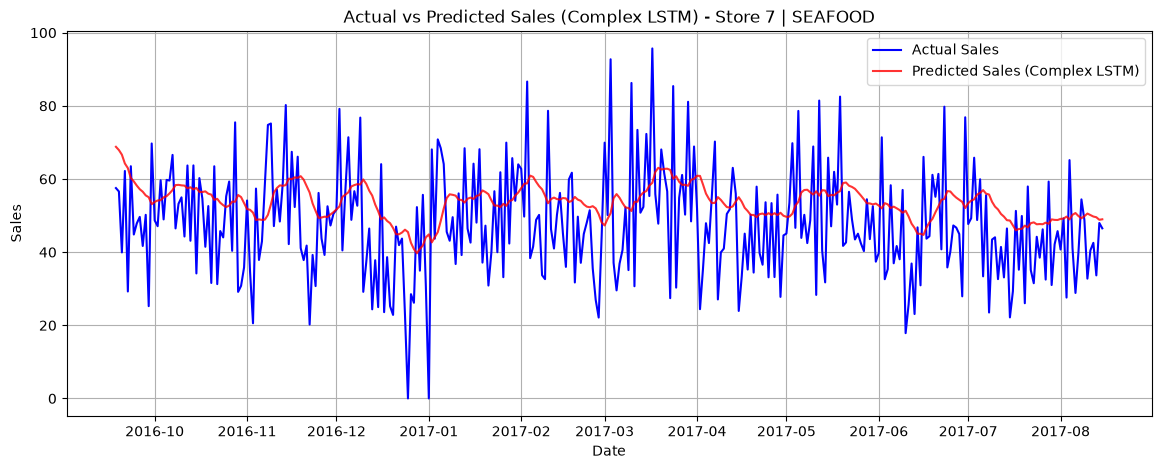

In [15]:
model_complex_comb4 = build_complex_lstm()
rmsle_complex_comb4 = train_and_evaluate(
    model_complex_comb4, data_comb4, 
    model_name="Complex LSTM", store_nbr=7, family="SEAFOOD", 
    epochs=50, batch_size=32
)

---
## Kombinasi 5: Store 23 - PREPARED FOODS

In [16]:
# Prepare Data Kombinasi 5 (Store 23, PREPARED FOODS)
data_comb5 = prepare_data_lstm(df_train, store_nbr=7, family='PREPARED FOODS')
print(f"Data Kombinasi 5 (Store 23 - PREPARED FOODS	) Siap!")
print(f"Shape X_train: {data_comb5['X_train'].shape}, Shape X_test: {data_comb5['X_test'].shape}")

Data Kombinasi 5 (Store 23 - PREPARED FOODS	) Siap!
Shape X_train: (1326, 30, 1), Shape X_test: (332, 30, 1)


### Kombinasi 5 - Model LSTM Sederhana

=== Training Simple LSTM (Store 23 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - loss: 0.0792 - val_loss: 0.0137
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0242 - val_loss: 0.0200
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0146 - val_loss: 0.0181
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0146 - val_loss: 0.0182
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0145 - val_loss: 0.0177
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0143 - val_loss: 0.0175
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0142 - val_loss: 0.0170
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0140 - val_loss: 0.0166
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0138 - val_loss: 0.0159
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0136 - val_loss: 0.0155
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0135 - val_loss: 0.0151
Epoch

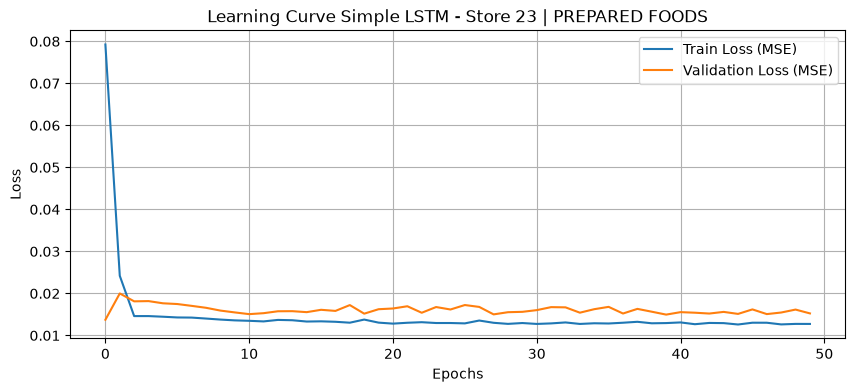

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
[Simple LSTM] RMSLE (Store 23 - PREPARED FOODS): 0.4420



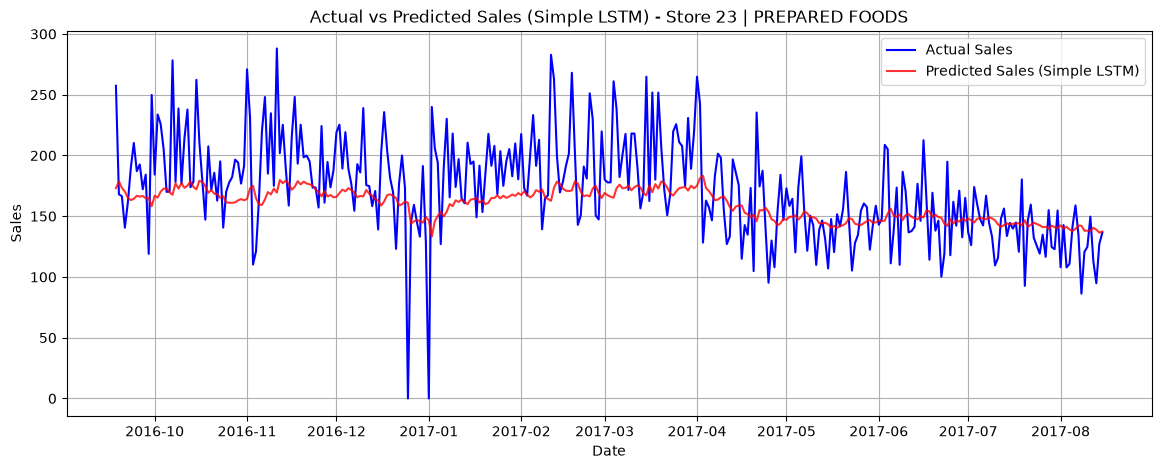

In [17]:
model_simple_comb5 = build_simple_lstm()
rmsle_simple_comb5 = train_and_evaluate(
    model_simple_comb5, data_comb5, 
    model_name="Simple LSTM", store_nbr=23, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

### Kombinasi 5 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 23 - PREPARED FOODS) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - loss: 0.0384 - val_loss: 0.0129
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0185 - val_loss: 0.0127
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0164 - val_loss: 0.0128
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0155 - val_loss: 0.0128
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0163 - val_loss: 0.0129
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - loss: 0.0155 - val_loss: 0.0128
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0152 - val_loss: 0.0128
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0153 - val_loss: 0.0129
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0159 - val_loss: 0.0130
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0148 - val_loss: 0.0128
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0158 - val_loss: 0.0128
Ep

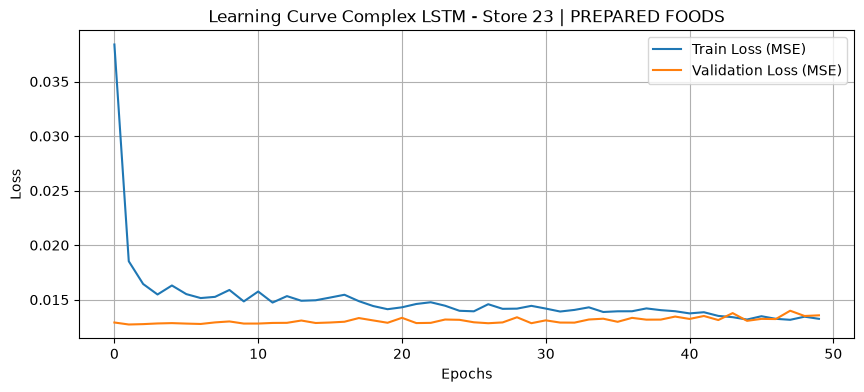

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
[Complex LSTM] RMSLE (Store 23 - PREPARED FOODS): 0.4495



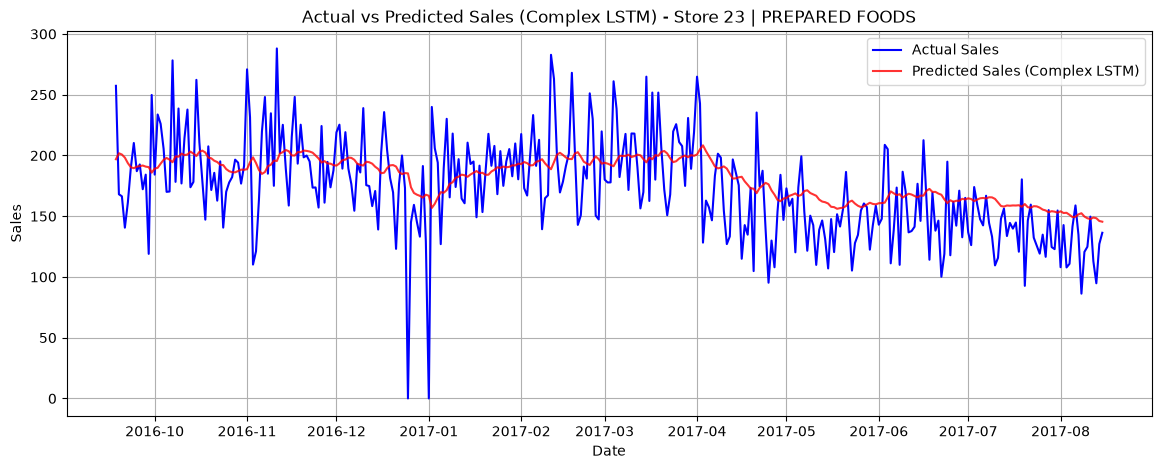

In [18]:
model_complex_comb5 = build_complex_lstm()
rmsle_complex_comb5 = train_and_evaluate(
    model_complex_comb5, data_comb5, 
    model_name="Complex LSTM", store_nbr=23, family="PREPARED FOODS", 
    epochs=50, batch_size=32
)

---
## Kombinasi 6: Store 44 - GROCERY I

In [19]:
# Prepare Data Kombinasi 6 (Store 44, GROCERY I)
data_comb6 = prepare_data_lstm(df_train, store_nbr=44, family='GROCERY I')
print(f"Data Kombinasi 6 (Store 44 - GROCERY I) Siap!")
print(f"Shape X_train: {data_comb6['X_train'].shape}, Shape X_test: {data_comb6['X_test'].shape}")

Data Kombinasi 6 (Store 44 - GROCERY I) Siap!
Shape X_train: (1326, 30, 1), Shape X_test: (332, 30, 1)


### Kombinasi 6 - Model LSTM Sederhana

=== Training Simple LSTM (Store 44 - GROCERY I) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0105 - val_loss: 0.0068
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0060 - val_loss: 0.0081
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0057 - val_loss: 0.0076
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0056 - val_loss: 0.0076
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0057 - val_loss: 0.0074
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0057 - val_loss: 0.0073
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0056 - val_loss: 0.0073
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0057 - val_loss: 0.0074
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0056 - val_loss: 0.0073
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0056 - val_loss: 0.0073
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0056 - val_loss: 0.0072
Epoch 12/50

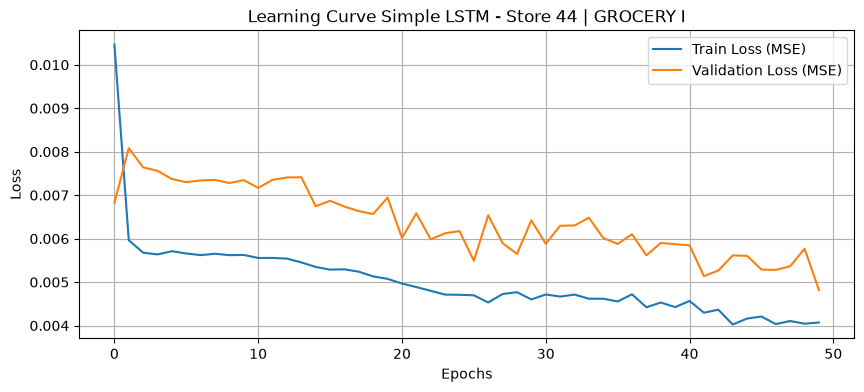

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
[Simple LSTM] RMSLE (Store 44 - GROCERY I): 0.7626



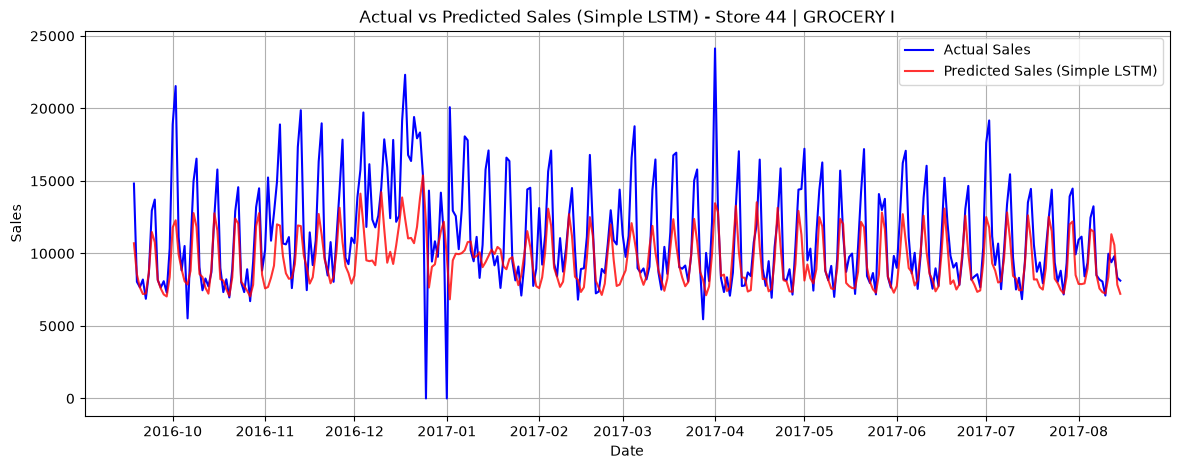

In [20]:
model_simple_comb6 = build_simple_lstm()
rmsle_simple_comb6 = train_and_evaluate(
    model_simple_comb6, data_comb6, 
    model_name="Simple LSTM", store_nbr=44, family="GROCERY I", 
    epochs=50, batch_size=32
)

### Kombinasi 6 - Model LSTM Kompleks (2 Layer + Dropout)

=== Training Complex LSTM (Store 44 - GROCERY I) ===
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - loss: 0.0099 - val_loss: 0.0072
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0060 - val_loss: 0.0065
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0061 - val_loss: 0.0063
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0058 - val_loss: 0.0062
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0060 - val_loss: 0.0063
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0059 - val_loss: 0.0062
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0060 - val_loss: 0.0062
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0058 - val_loss: 0.0063
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0058 - val_loss: 0.0063
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0058 - val_loss: 0.0063
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0058 - val_loss: 0.0063
Epoch 12/5

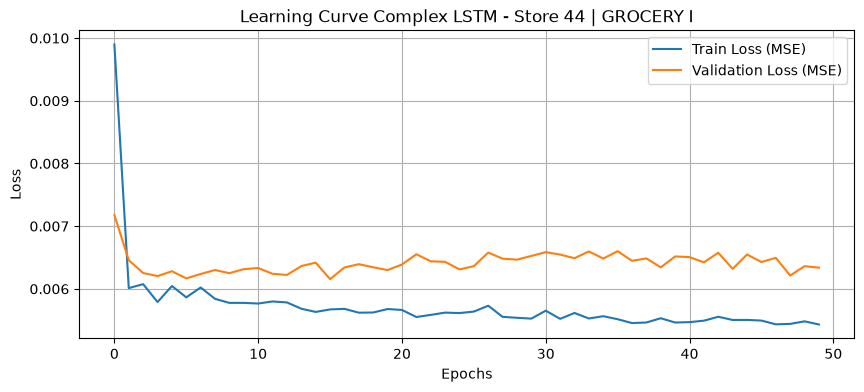

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
[Complex LSTM] RMSLE (Store 44 - GROCERY I): 0.7834



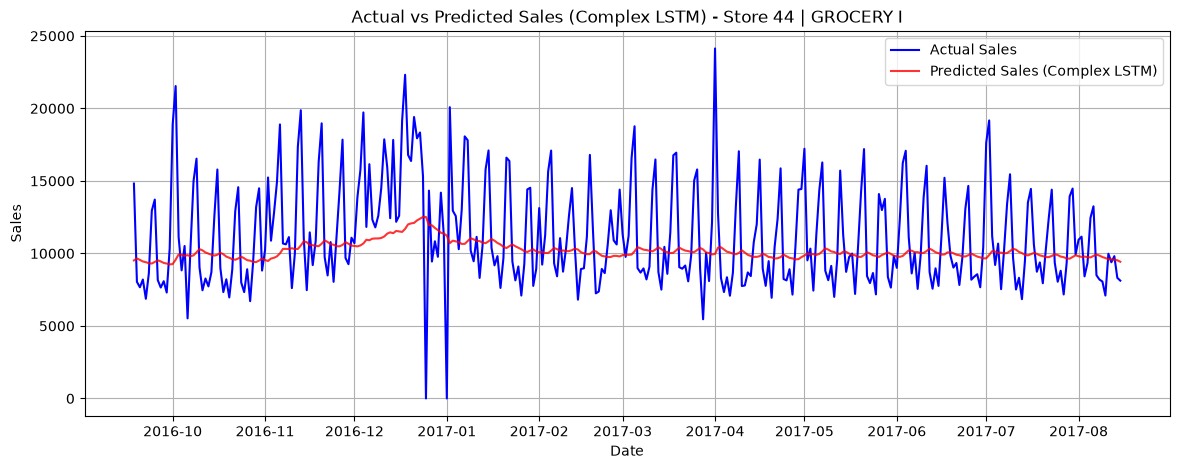

In [21]:
model_complex_comb6 = build_complex_lstm()
rmsle_complex_comb6 = train_and_evaluate(
    model_complex_comb6, data_comb6, 
    model_name="Complex LSTM", store_nbr=44, family="GROCERY I", 
    epochs=50, batch_size=32
)

---
## Ringkasan Perbandingan Performa Eksperimen

In [22]:
summary_data = [
    {'Store': 23, 'Family': 'EGGS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb1},
    {'Store': 23, 'Family': 'EGGS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb1},
    {'Store': 54, 'Family': 'MEATS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb2},
    {'Store': 54, 'Family': 'MEATS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb2},
    {'Store': 19, 'Family': 'PREPARED FOODS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb3},
    {'Store': 19, 'Family': 'PREPARED FOODS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb3},
    {'Store': 7, 'Family': 'SEAFOOD', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb4},
    {'Store': 7, 'Family': 'SEAFOOD', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb4},
    {'Store': 23, 'Family': 'PREPARED FOODS', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb5},
    {'Store': 23, 'Family': 'PREPARED FOODS', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb5},
    {'Store': 44, 'Family': 'GROCERY I', 'Model': 'Simple LSTM', 'RMSLE': rmsle_simple_comb6},
    {'Store': 44, 'Family': 'GROCERY I', 'Model': 'Complex LSTM', 'RMSLE': rmsle_complex_comb6},
]

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Store,Family,Model,RMSLE
0,23,EGGS,Simple LSTM,0.366183
1,23,EGGS,Complex LSTM,0.373250
2,54,MEATS,Simple LSTM,0.395549
3,54,MEATS,Complex LSTM,0.390116
4,19,PREPARED FOODS,Simple LSTM,0.427607
5,19,PREPARED FOODS,Complex LSTM,0.417431
6,7,SEAFOOD,Simple LSTM,0.424113
7,7,SEAFOOD,Complex LSTM,0.449377
8,23,PREPARED FOODS,Simple LSTM,0.441954
9,23,PREPARED FOODS,Complex LSTM,0.449548
